# Project Name - Netflix Data Anaytics

# Project Type - EDA

# Name - Saurabh Shukla

##  Project Summary -

This project presents an Exploratory Data Analysis (EDA) of the Netflix Titles Dataset to understand content distribution, growth trends, audience targeting, and global representation. The dataset was cleaned and preprocessed by handling missing values, standardizing formats, and creating new features such as content age and content addition year.

The analysis reveals that Movies dominate Netflix’s catalog, while TV Shows have grown significantly over recent years. Content additions increased rapidly between 2016 and 2020, highlighting Netflix’s expansion and investment in original productions. Genre analysis shows that International Movies, Dramas, Comedies, Action & Adventure, and Documentaries are among the most popular categories.

Country-wise analysis identifies the United States, India, the United Kingdom, Canada, and Japan as major content contributors, reflecting Netflix’s strong global presence. Rating analysis indicates a primary focus on mature and young-adult audiences, supported by a smaller collection of family-friendly content.

Further analysis of movie durations, TV show seasons, content age, and textual descriptions provides insights into viewing patterns and content diversity. Overall, the project highlights Netflix’s movie-centric catalog, diverse genre portfolio, global content strategy, and audience-focused approach, demonstrating how data-driven insights can support decision-making in the streaming entertainment industry.

# Let's Begin !

# Load the required libraries

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Load the data

In [65]:
netflix_df = pd.read_csv("/content/netflix_titles.csv")

In [66]:
netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Get a concise summary of DataFrame

In [67]:
netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


**Insights:**
- The dataset contains 8,807 Netflix titles and 12 features, providing information about movies and TV shows available on the platform.
- Several columns contain missing values, with the director column having the highest number of missing records, followed by cast, country, date_added, rating, and duration.
- Most columns are stored as object (string) data type, while release_year is the only numerical feature.
- The date_added column is currently stored as an object and should be converted to datetime format for time-based analysis such as yearly or monthly content additions.
- The dataset occupies approximately 825.8 KB of memory, making it lightweight and suitable for exploratory data analysis.

# Data Cleaning and Transformation

Exact count of the missing values

In [68]:
netflix_df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


# Handle the 'director' and 'cast' column.

In [69]:
# Handle missing values in 'director' and 'cast' columns
# These are categorical/text-based features with a large number of missing records.
# Missing values are replaced with 'Unknown' to preserve all rows and avoid data loss.
netflix_df['director'] = netflix_df['director'].fillna('Unknown')
netflix_df['cast'] = netflix_df['cast'].fillna('Unknown')

**Insight:**

Missing values in the director and cast columns were replaced with 'Unknown' instead of removing rows, ensuring that no content records were lost during data cleaning.
This approach preserves the dataset size and allows these columns to be used in further analysis without introducing null values.

In [70]:
netflix_df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,831
date_added,10
release_year,0
rating,4
duration,3


Handle the 'country' column

In [71]:
# Handle missing values in the 'country' column.
# Missing countries are replaced with the most frequently occurring country (mode).
# This helps retain all records while using the most repr
mode_country = netflix_df['country'].mode()[0]
netflix_df['country'] = netflix_df['country'].fillna(mode_country)

In [72]:
netflix_df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,4
duration,3


# Handle missing values in 'date_added', 'rating', and 'duration'.

In [73]:
# These columns contain only a few missing records (< 0.2% of the dataset).
# Dropping these rows has a negligible impact on the overall analysis.

netflix_df.dropna(subset = ['date_added', 'rating', 'duration'], inplace = True)

**Insight:**

The columns date_added, rating, and duration contained only a handful of missing values (17 records in total).
Since these missing values account for less than 0.2% of the dataset, the affected rows were removed to maintain data quality without significantly reducing the dataset size.
This approach is preferable to imputation because the number of missing records is very small and unlikely to influence overall trends.

In [74]:
netflix_df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


The dataset is now fully cleaned with no missing values, providing a reliable foundation for further analysis and visualization.

# Data Type Inconsistency in the 'date_added' column

In [75]:
# Convert 'date_added' from object to datetime format
# This enables time-based analysis such as yearly and monthly content additions.
netflix_df['date_added'] = pd.to_datetime(netflix_df['date_added'], format='mixed', dayfirst=False)

**Insight:**

The date_added column was converted from object to datetime format to enable time-series analysis.
This transformation allows extraction of useful features such as year, month, and day of content addition.
Converting to datetime improves data consistency and facilitates trend analysis of Netflix content additions over time.

# **Feature Engineering:**  Extracting Year and Month from Date Added

In [76]:
# Create new features from the 'date_added' column
# These features will help analyze content addition trends over years and months.
netflix_df['year_added'] = netflix_df['date_added'].dt.year
netflix_df['month_added'] = netflix_df['date_added'].dt.month

**Insights:**

- Two new features, year_added and month_added, were extracted from the date_added column.
- These derived features simplify temporal analysis by enabling the study of content additions across different years and months.
- Feature engineering enhances the dataset by creating additional variables without introducing new data.
- The new columns will help identify growth patterns and seasonal trends in Netflix's content catalog.

In [77]:
# Verify our cleaning and transformation
print("Missing values after cleaning: ")
print(netflix_df.isnull().sum())
print("\nData types after transformation:")
print(netflix_df.dtypes)

Missing values after cleaning: 
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
dtype: int64

Data types after transformation:
show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
year_added               int32
month_added              int32
dtype: object


Missing values were successfully handled, data types were corrected, and new time-based features were created. The dataset is now clean, consistent, and ready for exploratory data analysis and visualization

# Exploratory Data Analysis (EDA)


## Univariate Analysis
Analysis of individual variables to understand their distribution and characteristics.

In [78]:
type_counts = netflix_df['type'].value_counts()
print(type_counts)

type
Movie      6126
TV Show    2664
Name: count, dtype: int64


**Insights:**

- Movies dominate the Netflix catalog, accounting for approximately 70% of the total content.
- TV Shows represent around 30% of the available titles.
- This indicates that Netflix has historically focused more on movie content than television series.
- The large difference between Movies and TV Shows suggests an imbalance in content type distribution.

# Pie Chart

Insight: The Netfix library is highly dominated by Movies, which make up roughly 70% of the content in this specific dataset

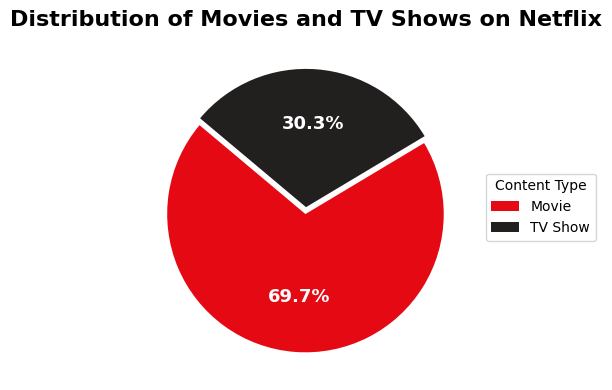

In [79]:
type_counts = netflix_df['type'].value_counts()

plt.figure(figsize=(6,4))

wedges, texts, autotexts = plt.pie(
    type_counts,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#E50914', '#221F1F'],
    explode=[0.05, 0]
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(13)
    autotext.set_weight('bold')

plt.legend(
    wedges,
    type_counts.index,
    title="Content Type",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title('Distribution of Movies and TV Shows on Netflix',
          fontsize=16,
          fontweight='bold')

plt.tight_layout()
plt.show()

# Content Added to Netflix Over Time

In [80]:
# Group data by year and content type
content_over_time = netflix_df.groupby(['year_added','type',]).size().unstack().fillna(0)
print(content_over_time)

type         Movie  TV Show
year_added                 
2008           1.0      1.0
2009           2.0      0.0
2010           1.0      0.0
2011          13.0      0.0
2012           3.0      0.0
2013           6.0      5.0
2014          19.0      5.0
2015          56.0     26.0
2016         251.0    175.0
2017         836.0    349.0
2018        1237.0    411.0
2019        1424.0    592.0
2020        1284.0    595.0
2021         993.0    505.0


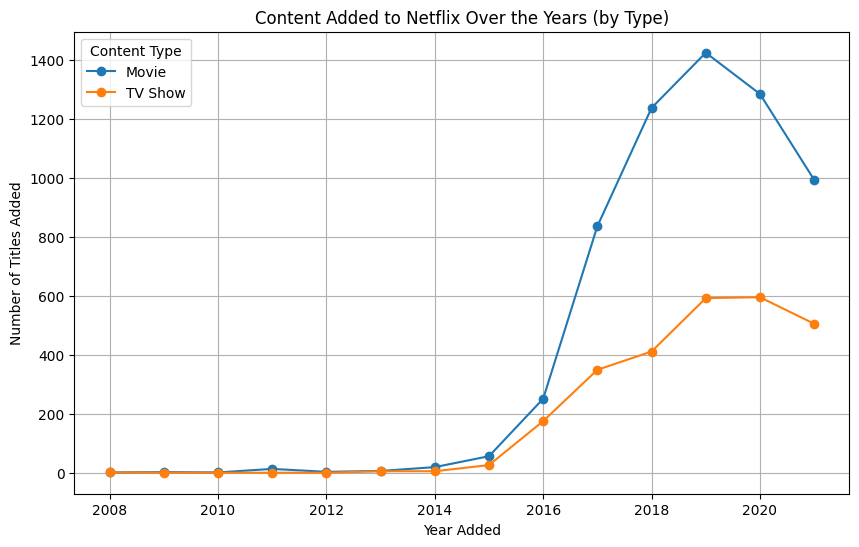

In [81]:
content_over_time.plot(kind='line', marker='o', figsize=(10,6))
plt.title('Content Added to Netflix Over the Years (by Type)')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
plt.legend(title='Content Type')
plt.grid(True)
plt.show()

**Insights: **

Both Movies and TV Shows experienced substantial growth in content additions between 2008 and 2020. However, the increase in Movies was much more pronounced, with movie additions reaching their peak in 2019. In contrast, TV Shows exhibited a more gradual and consistent growth pattern over the years. A decline in content additions can be observed in 2020 and 2021, which may be attributed to disruptions caused by the COVID-19 pandemic or the possibility that the dataset does not contain complete records for the most recent years.

# What are the most popular genres on Netflix?

In [82]:
# Split multiple genres in the 'listed_in' column
# and create a separate row for each genre.
genres = netflix_df.assign(
    genre=netflix_df['listed_in'].str.split(',')
).explode('genre')

In [83]:
genre_counts = genres['genre'].str.strip().value_counts()

print(genre_counts.head(10))

genre
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


Most popular genres

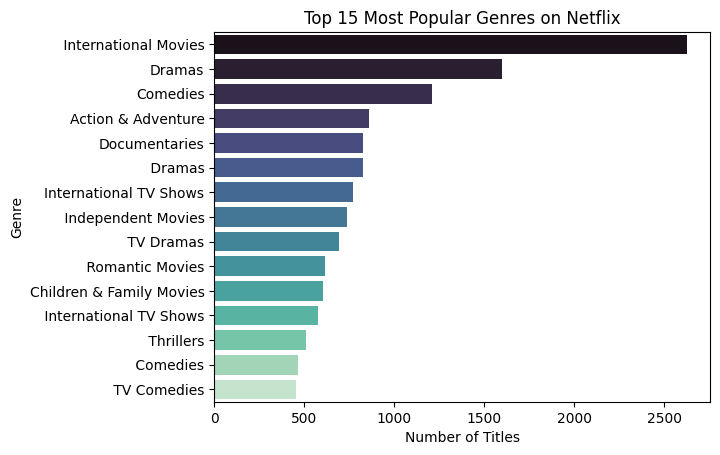

In [84]:
# Get the top 15 genres and their counts
top_genres_counts = genres['genre'].value_counts().reset_index()

# Rename columns for clarity
top_genres_counts.columns = ['genre', 'count']

# Select only the top 15 for plotting
top_genres_counts_plot = top_genres_counts.head(15)

sns.barplot(y='genre', x='count', data=top_genres_counts_plot, palette='mako', hue='genre', legend=False)
plt.title('Top 15 Most Popular Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

Insight: International Movies is the most dominant genre on Netflix, followed by Dramas and Comedies. This highlights Netflix's strong focus on serving a global audience through diverse international content. The high presence of drama and comedy genres suggests that viewers prefer storytelling-driven and entertainment-oriented content. Overall, the genre distribution reflects Netflix's strategy of maintaining a broad and diverse content library to cater to different audience preferences worldwide.

# Analyzing Duration Distribution of Movies and TV Shows

In [85]:
movies_df = netflix_df[netflix_df['type'] == 'Movie'].copy()
tv_shows_df = netflix_df[netflix_df['type'] == 'TV Show'].copy()

In [86]:
print("Movies:", movies_df.shape[0])
print("TV Shows:", tv_shows_df.shape[0])

Movies: 6126
TV Shows: 2664


The dataset was separated into Movies and TV Shows to analyze their duration distributions independently. Since movie duration is measured in minutes while TV Show duration is represented by seasons, analyzing them separately ensures meaningful comparisons and avoids mixing two different measurement scales.

In [87]:

# Extract movie duration in minutes and convert it to integer format
movies_df['duration_min'] = movies_df['duration'].str.replace(' min', '').astype(int)

# Extract the number of seasons for TV Shows and convert it to integer format
tv_shows_df['seasons'] = tv_shows_df['duration'].str.replace(' Seasons', '').str.replace(' Season', '').astype(int)

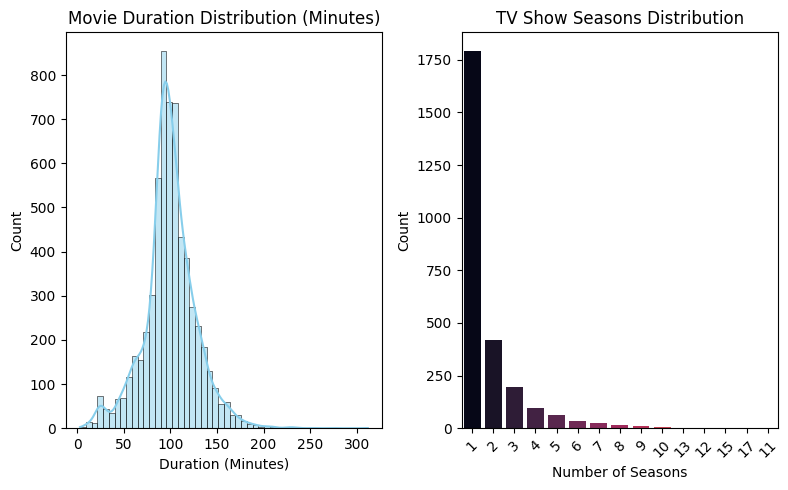

In [88]:
# Plot the distributions
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# Movie Duration Distribution
sns.histplot(
    data=movies_df,
    x='duration_min',
    bins=50,
    kde=True,
    color='skyblue',
    ax=axes[0]
)

axes[0].set_title('Movie Duration Distribution (Minutes)')
axes[0].set_xlabel('Duration (Minutes)')
axes[0].set_ylabel('Count')

# TV Show Seasons Distribution
sns.countplot(
    data=tv_shows_df,
    x='seasons',
    hue='seasons',
    palette='rocket',
    order=tv_shows_df['seasons'].value_counts().index,
    legend=False,
    ax=axes[1]
)

axes[1].set_title('TV Show Seasons Distribution')
axes[1].set_xlabel('Number of Seasons')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Insights:

• Most Netflix movies have a duration between 80 and 120 minutes, with the highest concentration around 90–100 minutes. This suggests that feature-length films dominate the platform's movie catalog.

• The movie duration distribution is approximately bell-shaped, indicating that extremely short or very long movies are relatively uncommon.

• Most TV Shows on Netflix have only one season, and the number of titles decreases significantly as the season count increases.

• Long-running TV Shows with many seasons are relatively rare, suggesting that Netflix's catalog is dominated by limited-series and short-format content.

# Top Content Producing Countries on Netflix

In [89]:
# Split multiple countries listed in the same title
# and create a separate row for each country.

countries = netflix_df.assign(
    country=netflix_df['country'].str.split(',')
).explode('country')

# Count the number of titles associated with each country
top_countries_counts = countries['country'].str.strip().value_counts().reset_index()

# Rename columns for better readability
top_countries_counts.columns = ['country', 'count']

# Display the top 15 content-producing countries
print(top_countries_counts.head(15))

           country  count
0    United States   4510
1            India   1046
2   United Kingdom    805
3           Canada    445
4           France    393
5            Japan    316
6            Spain    232
7      South Korea    231
8          Germany    226
9           Mexico    169
10           China    162
11       Australia    158
12           Egypt    117
13          Turkey    113
14       Hong Kong    105


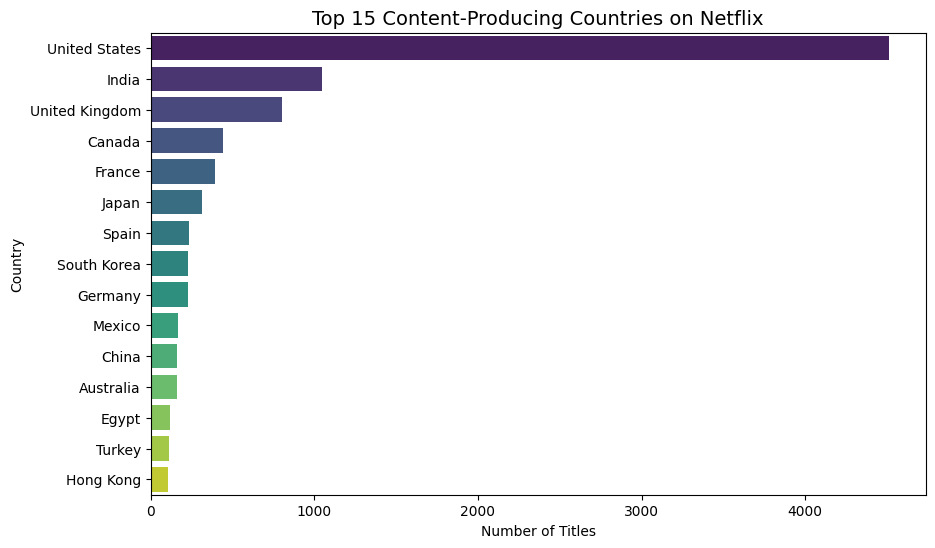

In [90]:
# Select the top 15 content-producing countries for visualization
top_countries_counts_plot = top_countries_counts.head(15)

plt.figure(figsize=(10,6))
sns.barplot(y='country', x='count', data=top_countries_counts_plot, palette='viridis', hue='country', legend=False)
plt.title('Top 15 Content-Producing Countries on Netflix', fontsize=14)
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

**Insights:**

- The United States is the largest contributor to Netflix's content library, producing significantly more titles than any other country.
- India ranks second, highlighting the strong presence of Indian entertainment content on the platform.
- The United Kingdom, Canada, and France are also among the top content-producing countries, making substantial contributions to Netflix's catalog.
- A large share of Netflix's content originates from a few major entertainment markets, particularly North America, Europe, and India.
- Despite the dominance of leading countries, Netflix maintains a globally diverse library with content sourced from many regions around the world.

# Maturity rating of the content

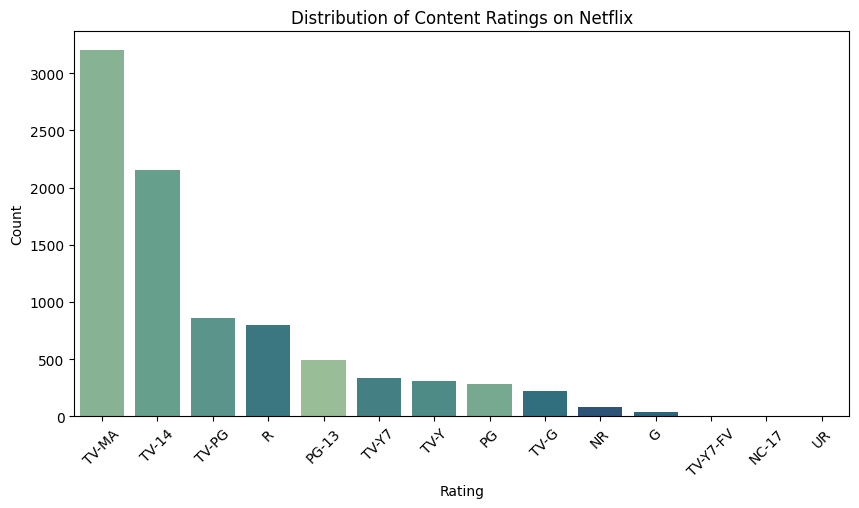

In [91]:
# Analyze the distribution of content ratings available on Netflix
plt.figure(figsize=(10,5))
sns.countplot(x='rating', data=netflix_df, order=netflix_df['rating'].value_counts().index, palette='crest', hue='rating')
plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

**Insight**

- TV-MA and TV-14 dominate Netflix's content library, indicating a strong focus on mature audiences and young adults.
- Family and children's content is available but represents a much smaller share of the catalog.
- Overall, Netflix's content portfolio is primarily targeted toward older viewers while still maintaining content for different age groups.

Feature Engineering

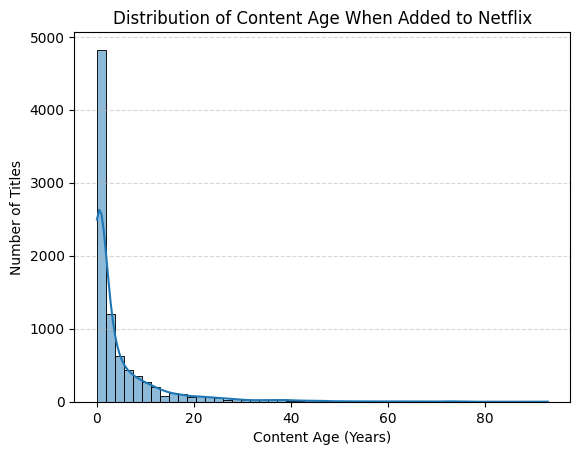

In [92]:
# Create a new feature to measure how old a title was
netflix_df['age_on_netflix'] = netflix_df['year_added'] - netflix_df['release_year']

# Remove any invalid records where the content appears
# to be added before its release year

content_age = netflix_df[netflix_df['age_on_netflix'] >= 0]

# Visualize the distribution of content age

sns.histplot(
    data=content_age,
    x='age_on_netflix',
    bins=50,
    kde=True
)

plt.title('Distribution of Content Age When Added to Netflix')
plt.xlabel('Content Age (Years)')
plt.ylabel('Number of Titles')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Insight:**

- Most Netflix titles are added shortly after their release, reflected by the strong peak near 0 years.
- The long right tail indicates that Netflix also includes older licensed movies and TV shows.
- This suggests a balanced strategy of offering both fresh content and classic titles in its library.

# Multivariate Analysis

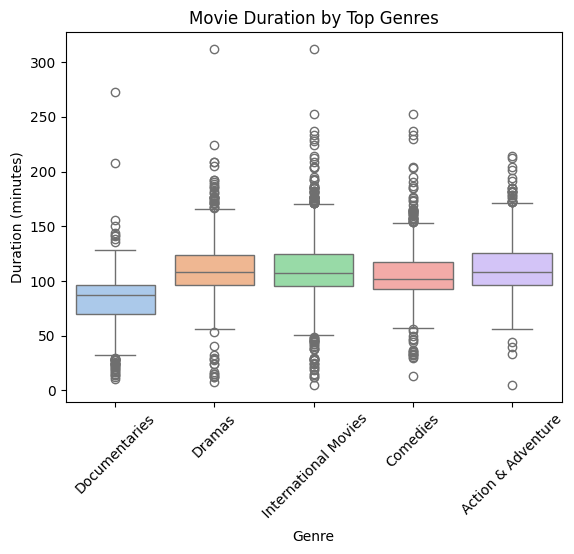

In [93]:
# Analyze movie duration across different top genres
top_genres = genres['genre'].value_counts().index[:5]

genres_movies = genres[
    (genres['type'] == 'Movie') &
    (genres['genre'].isin(top_genres))
].copy()

genres_movies['duration_min'] = genres_movies['duration'].str.replace(' min', '').astype(int)

sns.boxplot(
    data=genres_movies,
    x='genre',
    y='duration_min',
    palette='pastel',
    hue='genre',
    legend=False
)

plt.title('Movie Duration by Top Genres')
plt.xlabel('Genre')
plt.ylabel('Duration (minutes)')
plt.xticks(rotation=45)
plt.show()

# **Insights**
- Documentaries generally have the shortest durations, with a lower median runtime compared to other genres.
- Dramas, International Movies, Comedies, and Action & Adventure tend to have similar median durations, typically around 100–110 minutes.
- International Movies show a wider spread in duration, indicating greater variation in runtime.
- Several genres contain outliers exceeding 200 minutes, suggesting the presence of unusually long films.
- Overall, most movies across the top genres fall within the 80–130 minute range, which aligns with the standard feature-film length.

# Word Cloud from the content description

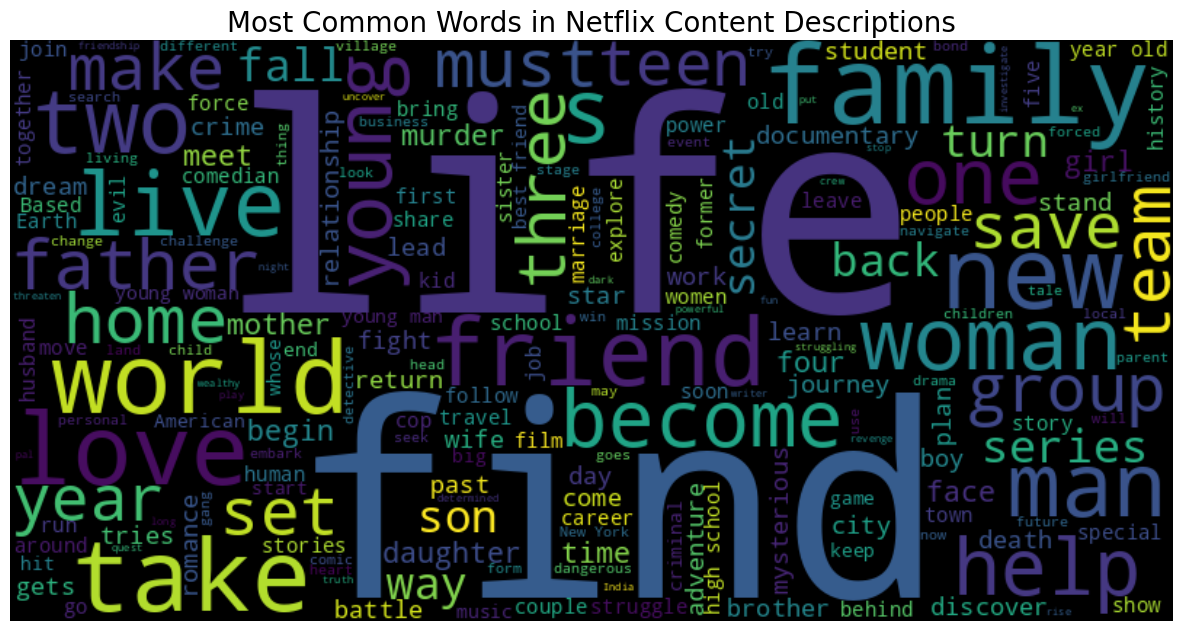

In [94]:
# Combine all descriptions into a single string
text = ' '.join(netflix_df['description'])

# Create and generate a word cloud image
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='black'
).generate(text)

# Display the generated image
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

plt.title(
    'Most Common Words in Netflix Content Descriptions',
    fontsize=20
)

plt.show()

**Insight:** The word cloud highlights common themes and subjects. Words like "life," "family," "love," "young," "friends," and "world" are prominent, suggesting that much of the content revolves around human relationships and personal journeys. Action-oriented words like "find," "secret," and "new" also appear frequently.

# Insight:

- Words like "life," "family," "love," "young," and "friend" dominate the descriptions, highlighting a strong focus on relationships and personal journeys.
- Adventure-related terms such as "find," "secret," "journey," and "team" are also common, reflecting the popularity of action and exploration themes.
- Overall, Netflix's content library appears to balance emotional storytelling with adventure and mystery-based narratives.

# **Conclusion & Key Findings**

## Key Findings and Business Insights

**1. Content Strategy**

- Netflix's catalog is heavily dominated by movies, which account for nearly 70% of all titles.
- Content additions grew rapidly between 2016 and 2019, reflecting an aggressive expansion strategy.
- The platform balances newly released titles, including Netflix Originals, with a large collection of older licensed content to maintain a diverse library.

**2. Global Content Presence**

- The United States is the largest contributor to Netflix's content library.
- India ranks as the second-largest contributor, highlighting the growing importance of Indian entertainment on the platform.
- The popularity of genres such as International Movies demonstrates Netflix's strong focus on serving a global audience.

**3. Target Audience**

- The majority of Netflix content is rated TV-MA and TV-14, indicating a primary focus on mature audiences and young adults.
- Family and children's content is available but represents a smaller share of the overall catalog.

**4. Content Format and Genre Preferences**

- Dramas and Comedies are among the most common genres on the platform.
- Most movies have a runtime between 90 and 120 minutes, aligning with standard feature-film durations.
-The majority of TV shows consist of a single season, suggesting that many series are either limited productions or do not continue beyond their initial season.

**5. Common Content Themes**

- Content descriptions frequently contain words related to life, family, love, friendship, and personal journeys.
- Adventure, discovery, and mystery-related themes also appear prominently, reflecting the diversity of storytelling available on Netflix.

# ** Limitations**

This dataset represents a snapshot of Netflix's catalog and does not include viewer engagement metrics such as watch time, ratings, or popularity.
Therefore, the analysis reflects the supply of content available on Netflix, rather than audience demand or content performance.
Despite these limitations, the EDA provides valuable insights into Netflix's content composition, growth patterns, audience focus, and global reach.